In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns
plt.rcParams['figure.figsize']=(10,10)

In [99]:
data=pd.read_csv(r"C:\Users\divya\Downloads\healthcare-dataset-stroke-data-balanced.csv")

In [100]:
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,40513,Female,21.0,0,0,No,Private,Urban,90.16,28.9,smokes,0
1,13861,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1
2,12857,Male,55.0,0,0,Yes,Self-employed,Rural,73.57,28.0,smokes,0
3,38673,Female,51.0,0,0,Yes,Private,Rural,105.63,32.8,never smoked,0
4,71673,Female,79.0,0,0,Yes,Private,Urban,110.85,24.1,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9717,67432,Female,60.0,0,0,Yes,Private,Urban,97.43,26.4,smokes,1
9718,62861,Female,78.0,0,0,Yes,Private,Urban,67.29,24.6,never smoked,1
9719,36857,Male,77.0,0,0,Yes,Self-employed,Rural,162.14,32.6,formerly smoked,1
9720,32240,Female,27.0,0,0,No,Private,Urban,93.55,41.6,never smoked,0


# Exploratory data analysis

In [101]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9722 non-null   int64  
 1   gender             9722 non-null   object 
 2   age                9722 non-null   float64
 3   hypertension       9722 non-null   int64  
 4   heart_disease      9722 non-null   int64  
 5   ever_married       9722 non-null   object 
 6   work_type          9722 non-null   object 
 7   Residence_type     9722 non-null   object 
 8   avg_glucose_level  9722 non-null   float64
 9   bmi                8750 non-null   float64
 10  smoking_status     9722 non-null   object 
 11  stroke             9722 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 911.6+ KB


In [102]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  972
smoking_status         0
stroke                 0
dtype: int64

# Fill BMI missing values

In [103]:
data['bmi'].value_counts()

bmi
31.4    120
27.3    117
24.0    103
27.5    102
27.7     99
       ... 
60.2      1
71.9      1
49.4      1
57.9      1
57.5      1
Name: count, Length: 418, dtype: int64

In [104]:
data['bmi'].describe()

count    8750.000000
mean       29.506651
std         7.187328
min        10.300000
25%        24.700000
50%        28.600000
75%        33.200000
max        97.600000
Name: bmi, dtype: float64

In [105]:
data['bmi'].fillna(data['bmi'].mean(),inplace=True)

C:\Users\divya\AppData\Local\Temp\ipykernel_31404\620513141.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].mean(),inplace=True)


In [106]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [107]:
data.drop('id',axis=1,inplace=True)

In [108]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,21.0,0,0,No,Private,Urban,90.16,28.9,smokes,0
1,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1
2,Male,55.0,0,0,Yes,Self-employed,Rural,73.57,28.0,smokes,0
3,Female,51.0,0,0,Yes,Private,Rural,105.63,32.8,never smoked,0
4,Female,79.0,0,0,Yes,Private,Urban,110.85,24.1,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
9717,Female,60.0,0,0,Yes,Private,Urban,97.43,26.4,smokes,1
9718,Female,78.0,0,0,Yes,Private,Urban,67.29,24.6,never smoked,1
9719,Male,77.0,0,0,Yes,Self-employed,Rural,162.14,32.6,formerly smoked,1
9720,Female,27.0,0,0,No,Private,Urban,93.55,41.6,never smoked,0


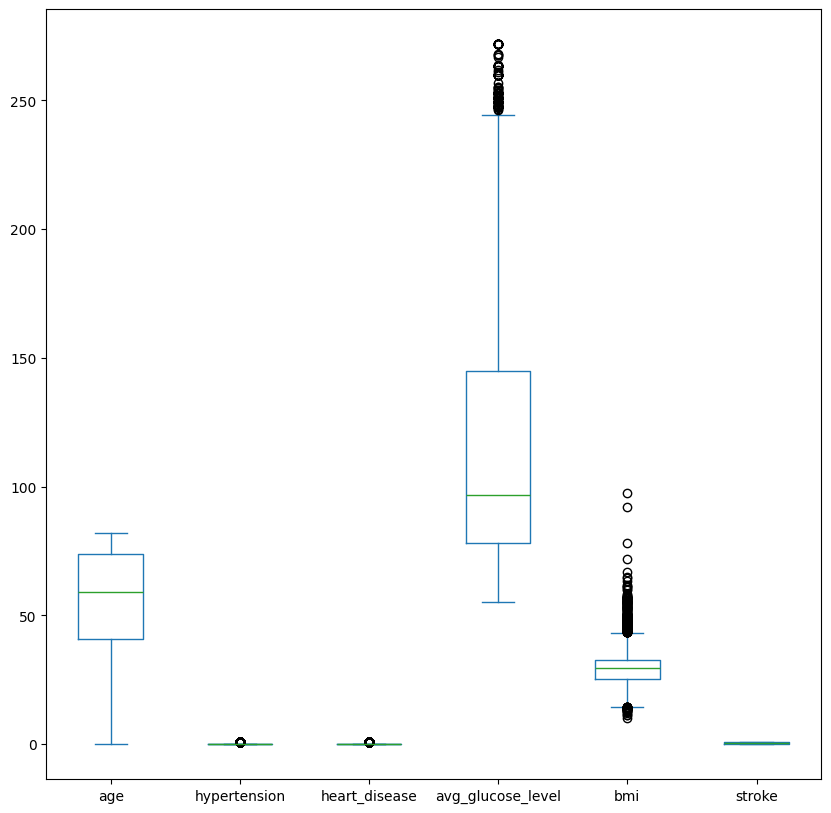

In [109]:
data.plot(kind='box')
plt.show()

In [110]:
# here we can see the outliers of the various features 
# avg_glucose_levelha so many outler values

In [111]:
data['avg_glucose_level'].describe()

count    9722.000000
mean      118.379963
std        55.194973
min        55.120000
25%        78.112500
50%        96.715000
75%       144.900000
max       271.740000
Name: avg_glucose_level, dtype: float64

In [112]:
# 75% data is 114. We can keep this data because people can have higher
# values of bmi or glucose because that may be the reason of the stroke

In [113]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,21.0,0,0,No,Private,Urban,90.16,28.9,smokes,0
1,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1
2,Male,55.0,0,0,Yes,Self-employed,Rural,73.57,28.0,smokes,0
3,Female,51.0,0,0,Yes,Private,Rural,105.63,32.8,never smoked,0
4,Female,79.0,0,0,Yes,Private,Urban,110.85,24.1,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
9717,Female,60.0,0,0,Yes,Private,Urban,97.43,26.4,smokes,1
9718,Female,78.0,0,0,Yes,Private,Urban,67.29,24.6,never smoked,1
9719,Male,77.0,0,0,Yes,Self-employed,Rural,162.14,32.6,formerly smoked,1
9720,Female,27.0,0,0,No,Private,Urban,93.55,41.6,never smoked,0


In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9722 non-null   object 
 1   age                9722 non-null   float64
 2   hypertension       9722 non-null   int64  
 3   heart_disease      9722 non-null   int64  
 4   ever_married       9722 non-null   object 
 5   work_type          9722 non-null   object 
 6   Residence_type     9722 non-null   object 
 7   avg_glucose_level  9722 non-null   float64
 8   bmi                9722 non-null   float64
 9   smoking_status     9722 non-null   object 
 10  stroke             9722 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 835.6+ KB


In [115]:
#Label Encoding
#as there are objects in the dataset . Machine will not understand the string values of
# work_type,marriage ,smoking values . we need to convert them into values so that machine will be
#able to understand the values

In [116]:
data['work_type'].unique()

array(['Private', 'Self-employed', 'children', 'Govt_job', 'Never_worked'],
      dtype=object)

In [117]:
# we can give values to these like 0,1,2,3 etc

# We are encoding the data here i.e giving values to the objects 

In [118]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()


In [119]:
gender=enc.fit_transform(data['gender'])

In [120]:
smoking_status=enc.fit_transform(data['smoking_status'])

In [121]:
work_type=enc.fit_transform(data['work_type'])
Residence_type=enc.fit_transform(data['Residence_type'])
ever_married=enc.fit_transform(data['ever_married'])

In [122]:
ever_married

array([0, 1, 1, ..., 1, 0, 1])

# Replacing the old values of features with the encoded values 

In [123]:
data['work_type']=work_type

In [124]:
data['ever_married']=ever_married
data['Residence_type']=Residence_type
data['smoking_status']=smoking_status
data['gender']=gender

In [125]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,21.0,0,0,0,2,1,90.16,28.9,3,0
1,0,52.0,1,0,1,3,1,233.29,48.9,2,1
2,1,55.0,0,0,1,3,0,73.57,28.0,3,0
3,0,51.0,0,0,1,2,0,105.63,32.8,2,0
4,0,79.0,0,0,1,2,1,110.85,24.1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9717,0,60.0,0,0,1,2,1,97.43,26.4,3,1
9718,0,78.0,0,0,1,2,1,67.29,24.6,2,1
9719,1,77.0,0,0,1,3,0,162.14,32.6,1,1
9720,0,27.0,0,0,0,2,1,93.55,41.6,2,0


In [126]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9722 non-null   int32  
 1   age                9722 non-null   float64
 2   hypertension       9722 non-null   int64  
 3   heart_disease      9722 non-null   int64  
 4   ever_married       9722 non-null   int32  
 5   work_type          9722 non-null   int32  
 6   Residence_type     9722 non-null   int32  
 7   avg_glucose_level  9722 non-null   float64
 8   bmi                9722 non-null   float64
 9   smoking_status     9722 non-null   int32  
 10  stroke             9722 non-null   int64  
dtypes: float64(3), int32(5), int64(3)
memory usage: 645.7 KB


# Partitioning

In [127]:
#Splitting the data for train and test

In [128]:
# X----- features(train_X,test_X) (80,20)
# Y-----target(labels of X) train_Y,test_Y

In [129]:
X=data.drop('stroke',axis=1)

In [130]:
X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,0,21.0,0,0,0,2,1,90.16,28.9,3
1,0,52.0,1,0,1,3,1,233.29,48.9,2
2,1,55.0,0,0,1,3,0,73.57,28.0,3
3,0,51.0,0,0,1,2,0,105.63,32.8,2
4,0,79.0,0,0,1,2,1,110.85,24.1,1
...,...,...,...,...,...,...,...,...,...,...
9717,0,60.0,0,0,1,2,1,97.43,26.4,3
9718,0,78.0,0,0,1,2,1,67.29,24.6,2
9719,1,77.0,0,0,1,3,0,162.14,32.6,1
9720,0,27.0,0,0,0,2,1,93.55,41.6,2


In [131]:
Y=data['stroke']

In [132]:
Y

0       0
1       1
2       0
3       0
4       1
       ..
9717    1
9718    1
9719    1
9720    0
9721    1
Name: stroke, Length: 9722, dtype: int64

In [133]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=101)

In [134]:
X_train

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
3679,0,43.0,0,0,1,0,1,104.55,23.9,3
1423,1,52.0,0,0,1,0,1,86.06,29.2,1
1041,0,12.0,0,0,0,4,0,132.85,16.2,2
6607,1,76.0,0,0,1,2,1,147.50,28.7,0
6749,1,78.0,0,0,1,3,0,126.39,21.3,3
...,...,...,...,...,...,...,...,...,...,...
599,1,80.0,0,1,1,2,0,105.92,32.5,2
5695,0,65.0,0,0,1,2,0,100.98,28.2,1
8006,1,57.0,1,0,1,0,1,78.92,27.7,1
1361,1,5.0,0,0,0,4,0,74.79,19.4,0


In [135]:
y_train

3679    0
1423    0
1041    0
6607    0
6749    0
       ..
599     1
5695    1
8006    1
1361    0
1547    0
Name: stroke, Length: 7777, dtype: int64

In [136]:
X_test

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
7343,0,72.0,0,0,1,0,1,131.41,28.4,2
2267,0,57.0,0,0,0,3,0,72.55,21.0,2
2773,0,75.0,1,0,1,3,1,55.96,34.8,2
3593,1,78.0,0,0,1,3,0,93.85,22.7,1
1214,0,56.0,0,0,1,2,1,185.17,40.4,1
...,...,...,...,...,...,...,...,...,...,...
6046,0,50.0,1,0,1,2,0,73.18,30.3,1
7815,0,49.0,0,0,1,2,1,105.99,29.8,2
2968,0,69.0,0,0,0,2,1,94.39,22.8,2
5707,1,50.0,0,0,1,2,0,93.04,41.9,3


In [137]:
Y_test

7343    1
2267    0
2773    0
3593    0
1214    1
       ..
6046    1
7815    0
2968    1
5707    0
5055    1
Name: stroke, Length: 1945, dtype: int64

# Normalisation

In [138]:
data.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000
mean,0.421210,54.916692,0.174861,0.122094,0.762703,2.089385,0.528492,118.379963,29.506651,1.439107,0.500000
std,0.493987,22.238642,0.379868,0.327411,0.425448,1.017556,0.499213,55.194973,6.818537,1.035053,0.500026
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000
25%,0.000000,41.000000,0.000000,0.000000,1.000000,2.000000,0.000000,78.112500,25.300000,0.000000,0.000000
50%,0.000000,59.000000,0.000000,0.000000,1.000000,2.000000,1.000000,96.715000,29.506651,2.000000,0.500000
75%,1.000000,74.000000,0.000000,0.000000,1.000000,3.000000,1.000000,144.900000,32.500000,2.000000,1.000000
max,2.000000,82.000000,1.000000,1.000000,1.000000,4.000000,1.000000,271.740000,97.600000,3.000000,1.000000


In [139]:
#data is not in a particular range . we need to bring it in a particular level 
#mean will be 0 . std deviation will be 1
#onr need to transfrom x 

In [140]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()

In [141]:
X_train_std=std.fit_transform(X_train)
X_test_std=std.transform(X_test)


In [142]:
#Lets save the scaler object

In [143]:
X_test_std

array([[-0.85516113,  0.76878691, -0.45954549, ...,  0.23605502,
        -0.16279514,  0.54259061],
       [-0.85516113,  0.09325049, -0.45954549, ..., -0.83058882,
        -1.25324084,  0.54259061],
       [-0.85516113,  0.9038942 ,  2.17606313, ..., -1.13122798,
         0.78029303,  0.54259061],
       ...,
       [-0.85516113,  0.63367963, -0.45954549, ..., -0.43481068,
        -0.98799729,  0.54259061],
       [ 1.16813918, -0.22199984, -0.45954549, ..., -0.45927498,
         1.82653147,  1.50687926],
       [ 1.16813918,  1.17410876, -0.45954549, ...,  1.71859209,
        -0.50171745, -1.3859867 ]])

In [144]:
X_train_std

array([[-0.85516113, -0.53725017, -0.45954549, ..., -0.25069411,
        -0.82590401,  1.50687926],
       [ 1.16813918, -0.13192832, -0.45954549, ..., -0.58576452,
        -0.04490912, -0.42169805],
       [-0.85516113, -1.93335877, -0.45954549, ...,  0.26215028,
        -1.96055697,  0.54259061],
       ...,
       [ 1.16813918,  0.09325049,  2.17606313, ..., -0.71515353,
        -0.26594541, -0.42169805],
       [ 1.16813918, -2.2486091 , -0.45954549, ..., -0.78999619,
        -1.48901289, -1.3859867 ],
       [-0.85516113, -0.35710712, -0.45954549, ..., -0.94638654,
         0.29401319,  0.54259061]])

# Training

# Decision Tree

In [145]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [146]:
dt.fit(X_train_std,y_train)

DecisionTreeClassifier()

In [147]:
dt.feature_importances_

array([0.01013811, 0.47647976, 0.0230766 , 0.01230529, 0.00440816,
       0.03375989, 0.00921107, 0.20471482, 0.16852205, 0.05738426])

In [148]:
X_train.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')

In [149]:
# here we can see age,avg_glucose and bmi are most imp factors

In [150]:
Y_pred=dt.predict(X_test_std)

In [151]:
Y_test

7343    1
2267    0
2773    0
3593    0
1214    1
       ..
6046    1
7815    0
2968    1
5707    0
5055    1
Name: stroke, Length: 1945, dtype: int64

In [152]:
print(f"Length of Y_test: {len(Y_test)}")
print(f"Length of Y_pred: {len(Y_pred)}")


Length of Y_test: 1945
Length of Y_pred: 1945


In [153]:
from sklearn.metrics import accuracy_score

In [154]:
ac_dt=accuracy_score(Y_test,Y_pred)

In [155]:
ac_dt

0.9789203084832905

In [156]:
# As we can see that accuracy tp DT algo is around 90%

# Logistic Regression

In [157]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [158]:
lr.fit(X_train_std,y_train)

LogisticRegression()

In [159]:
Y_pred=lr.predict(X_test_std)

In [160]:
ac_lr=accuracy_score(Y_test,Y_pred)

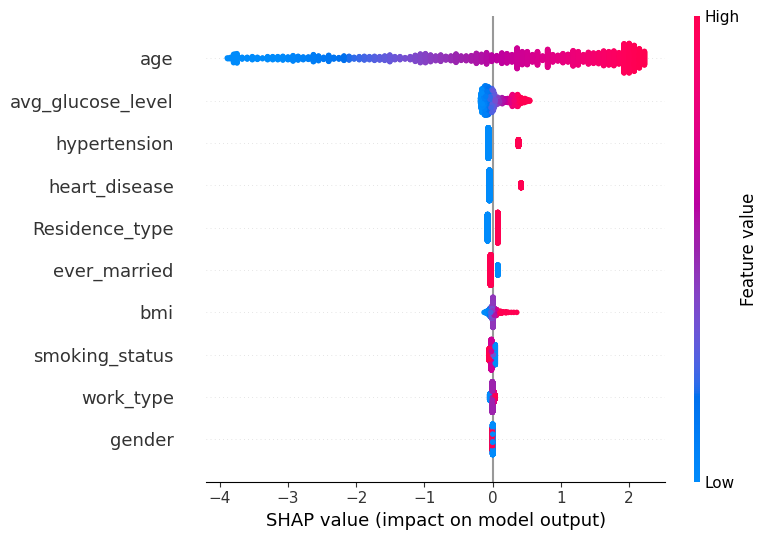

In [161]:
# Explainable AI with SHAP for Logistic Regression
import shap
from sklearn.linear_model import LogisticRegression

# Fit the Logistic Regression model
logreg = LogisticRegression(max_iter=1000)  # You can adjust parameters as needed
logreg.fit(X_train, y_train)  # X_train and y_train should be your training data

# Create SHAP explainer using LinearExplainer (since Logistic Regression is a linear model)
explainer = shap.LinearExplainer(logreg, X_train)  # X_train as background dataset

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)  # SHAP values for all classes

# Ensure the shapes match and visualize
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test, feature_names=X_test.columns)  # For class 1 (positive class)
else:
    shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)   


In [162]:
ac_lr

0.7799485861182519

In [163]:
# Accuracy of LR algo is around 94.7%

# KNN

In [164]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [165]:
knn.fit(X_train_std,y_train)

KNeighborsClassifier()

In [166]:
Y_pred=knn.predict(X_test_std)

In [167]:
ac_knn=accuracy_score(Y_test,Y_pred)

In [168]:
ac_knn

0.9347043701799486

In [169]:
#Accuracy of KNN algo is around 94.5%

# Random Forest algo

In [170]:
from sklearn.ensemble import RandomForestClassifier
rf =RandomForestClassifier()

In [171]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [172]:
Y_pred=rf.predict(X_test)

In [173]:
ac_rf=accuracy_score(Y_test,Y_pred)

In [174]:

# Explainable AI with SHAP for Random Forest
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)






In [175]:
print(len(shap_values))  # Number of classes
print(shap_values[0].shape)  # SHAP values for class 0
print(shap_values[1].shape)  # SHAP values for class 1


1945
(10, 2)
(10, 2)


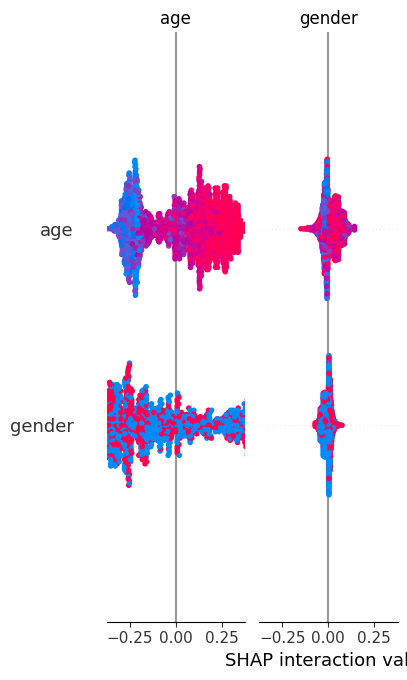

In [176]:
# Ensure the shapes match and visualize
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test, feature_names=X_test.columns)
else:
    shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)


In [177]:
sample_index = 0 
print("SHAP values shape:", shap_values[1][sample_index].shape)
print("Features shape:", X_test.iloc[sample_index].shape)


SHAP values shape: (2,)
Features shape: (10,)


In [178]:
sample_index = 0 
print("X_test columns:", X_test.columns)
print("SHAP values shape:", shap_values[1][sample_index].shape)
print("X_test shape:", X_test.iloc[sample_index].shape)


X_test columns: Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')
SHAP values shape: (2,)
X_test shape: (10,)


In [179]:
ac_rf

0.9958868894601542

In [180]:
#Accuracy score is 94.61%

# SVM



In [181]:
from sklearn.svm import SVC

In [182]:
sv=SVC()

In [183]:
sv.fit(X_train_std,y_train)

SVC()

In [184]:
Y_pred=sv.predict(X_test_std)

In [185]:
ac_sv=accuracy_score(Y_test,Y_pred)

In [186]:
ac_sv

0.8318766066838046

In [187]:
# Accuracy score of SVM is 94.71%



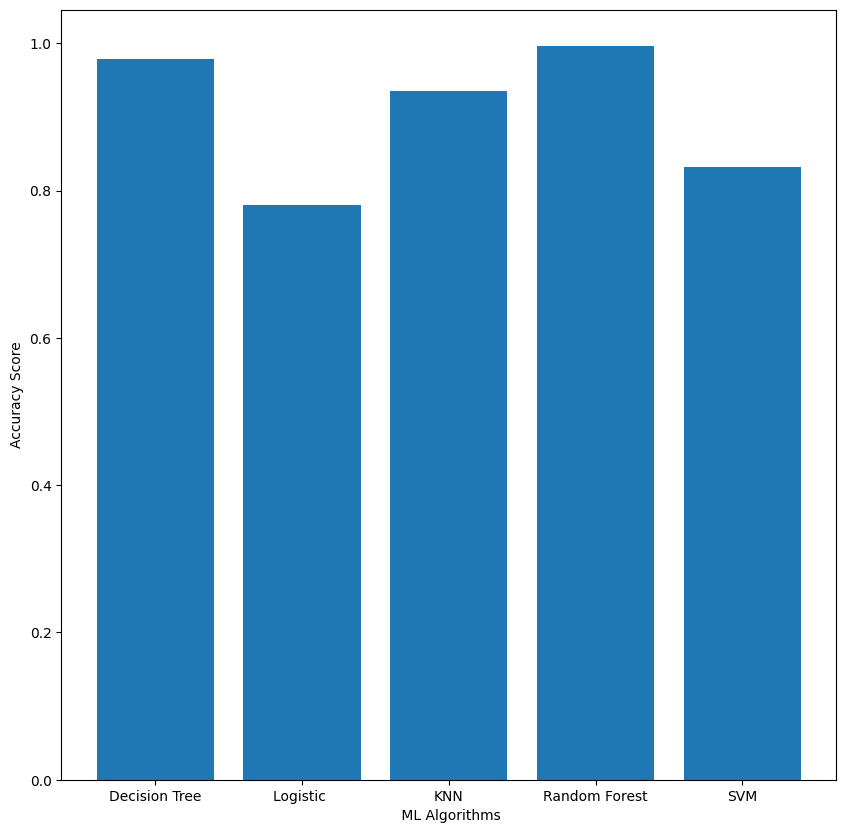

In [188]:
plt.bar(['Decision Tree', 'Logistic ','KNN', 'Random Forest','SVM'], [ac_dt,ac_lr,ac_knn,ac_rf,ac_sv])
plt.xlabel(" ML Algorithms")
plt.ylabel("Accuracy Score")
plt.show()

In [189]:
import pickle


In [190]:
import os

scaler_path=os.path.join(r"C:/Users/divya/Downloads/project-bolt-sb1-lnbljvcu (2)/project/","backend/scaler.pkl")
with open (scaler_path,'wb') as scaler_file:
    pickle.dump(std,scaler_file)




In [191]:
import joblib
model_path=os.path.join('C:/Users/divya/Downloads/project-bolt-sb1-lnbljvcu (2)/project','backend/dt.sav')
joblib.dump(dt,model_path)

import pickle
filename=r'C:\Users\divya\Downloads\project-bolt-sb1-lnbljvcu (2)\project\backend\finalized_model.sav'
pickle.dump(lr,open(filename, 'wb'))


print(f"Model Exists: {os.path.exists(model_path)}")
print(f"Scaler Exists: {os.path.exists(scaler_path)}")

MODEL_PATH = os.path.abspath(r"C:\Users\divya\Downloads\project-bolt-sb1-lnbljvcu (1)\project\backend\scaler.pkl")
print(f"Loading model from: {MODEL_PATH}")


Model Exists: True
Scaler Exists: True
Loading model from: C:\Users\divya\Downloads\project-bolt-sb1-lnbljvcu (1)\project\backend\scaler.pkl


In [192]:
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load your dataset
data = pd.read_csv(r"C:\Users\divya\Downloads\healthcare-dataset-stroke-data-balanced.csv")

# Separate features and target variable
X = data.drop(columns=["stroke"])  # Adjust according to your dataset
Y = data["stroke"]



# Encode categorical features
X_encoded = X.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype == 'object' else col)

# Convert to numpy
X = X_encoded.to_numpy()

# Define Genetic Algorithm (GA) parameters
num_features = X.shape[1]

# Define Fitness Function
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Initialize Individual and Population
toolbox = base.Toolbox()
toolbox.register("attr_bool", np.random.randint, 0, 2)  # 0 or 1 for feature selection
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, num_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Define Evaluation Function
def evaluate(individual):
    selected_indices = [i for i in range(num_features) if individual[i] == 1]
    if len(selected_indices) == 0:
        return (0,)  # Avoid empty selection

    X_selected = X[:, selected_indices]

    # Split Data
    X_train, X_test, Y_train, Y_test = train_test_split(X_selected, Y, test_size=0.2, random_state=42)

    # Train Classifier
    model = RandomForestClassifier(n_estimators=50, random_state=42)
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    return (accuracy_score(Y_test, Y_pred),)

# Register Genetic Algorithm Operators
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Run Genetic Algorithm
def run_ga():
    population = toolbox.population(n=20)  # Initialize Population
    ngen, cxpb, mutpb = 10, 0.5, 0.2  # Generations, Crossover, Mutation Probability

    algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen, stats=None, halloffame=None, verbose=False)

    # Best Individual (Best Feature Set)
    best_individual = tools.selBest(population, k=1)[0]
    selected_features = [X_encoded.columns[i] for i in range(num_features) if best_individual[i] == 1]

    print("\nSelected Features:", selected_features)  # Simple Output
    return selected_features

# Run GA for Feature Selection
best_features = run_ga()


C:\Users\divya\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\divya\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "



Selected Features: ['id', 'gender', 'hypertension', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


In [195]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Selected features
selected_feature_names = [ 'gender', 'hypertension', 'heart_disease', 'work_type', 'avg_glucose_level', 'bmi', 'smoking_status']

# Handle NaN values using imputation (fills missing values with column mean)
imputer = SimpleImputer(strategy="mean")
X_selected = imputer.fit_transform(X_encoded[selected_feature_names])  # Convert to NumPy

# Split Data
X_train, X_test, Y_train, Y_test = train_test_split(X_selected, Y, test_size=0.2, random_state=42)

# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, Y_train)

# Predict on test set
Y_pred = log_reg.predict(X_test)

# Compute Accuracy
accuracy1 = accuracy_score(Y_test, Y_pred)
print("\nLogistic Regression Accuracy on Selected Features:", accuracy1)



Logistic Regression Accuracy on Selected Features: 0.6863753213367609


In [194]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Selected features
selected_feature_names = ['id', 'gender', 'hypertension', 'heart_disease', 'work_type', 'avg_glucose_level', 'bmi', 'smoking_status']

# Handle NaN values using imputation
imputer = SimpleImputer(strategy="mean")  # Fill missing values with mean
X_selected = imputer.fit_transform(X_encoded[selected_feature_names])  # Convert to NumPy

# Split Data
X_train, X_test, Y_train, Y_test = train_test_split(X_selected, Y, test_size=0.2, random_state=42)

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

# Predict on test set
Y_pred = dt_model.predict(X_test)

# Compute Accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print("\nDecision Tree Accuracy on Selected Features:", accuracy)



Decision Tree Accuracy on Selected Features: 0.9773778920308483


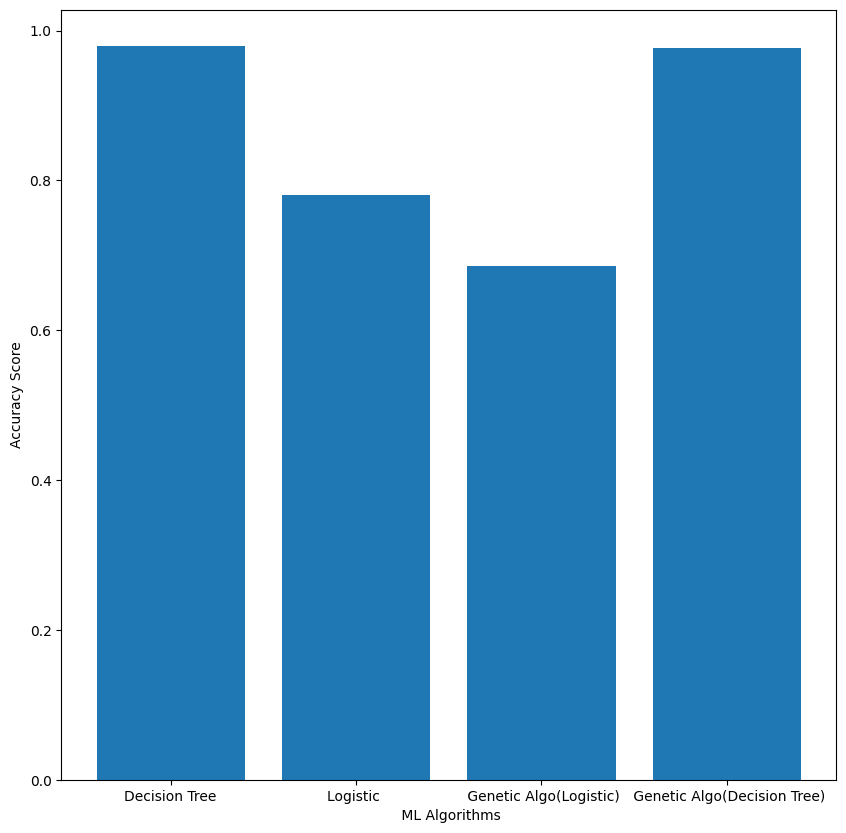

In [198]:
plt.bar(['Decision Tree', 'Logistic ',' Genetic Algo(Logistic)', ' Genetic Algo(Decision Tree)'], [ac_dt,ac_lr,accuracy1,accuracy])
plt.xlabel(" ML Algorithms")
plt.ylabel("Accuracy Score")
plt.show()